# Pilot Figure Generation

This notebook generates pilot validation figures for one resting-state fMRI run:

```text
sub-PC001 / ses-01 / task-rest / run-1
```

The figures are used as workflow-validation outputs and should not be interpreted as evidence for psychedelic-related effects or group-level findings.


In [19]:
import os
from pathlib import Path

print("Current working directory:")
print(os.getcwd())

print("\nFiles in current directory:")
for f in os.listdir("."):
    print(f)

Current working directory:
/content

Files in current directory:
.config
roi_timeseries_heatmap_dark.png
static_fc_fisher_z_heatmap_dark.png
sub-PC001_ses-01_task-rest_run-1_roi_timeseries_z.csv
sub-PC001_ses-01_task-rest_run-1_static_fc.csv
static_fc_heatmap_dark.png
sample_data


In [23]:
# upload static fc
from google.colab import files
uploaded = files.upload()

Saving sub-PC001_ses-01_task-rest_run-1_static_fc.csv to sub-PC001_ses-01_task-rest_run-1_static_fc (2).csv


In [25]:
# upload static fc fisher-z
from google.colab import files
uploaded = files.upload()

Saving sub-PC001_ses-01_task-rest_run-1_static_fc_fisher_z.csv to sub-PC001_ses-01_task-rest_run-1_static_fc_fisher_z (1).csv


In [26]:
import pandas as pd
import numpy as np
from scipy.stats import zscore

roi_path = "/content/sub-PC001_ses-01_task-rest_run-1_roi_timeseries_z.csv"
df = pd.read_csv(roi_path)

print("Raw shape:", df.shape)
print(df.head())

arr = df.values

# 如果有非數值欄位，改用只取數值欄位
arr = df.select_dtypes(include=[np.number]).values

print("Numeric array shape:", arr.shape)

# 確保 time x roi
if arr.shape[0] == 504 and arr.shape[1] == 67:
    ts = arr
elif arr.shape[0] == 67 and arr.shape[1] == 504:
    ts = arr.T
else:
    print("Unexpected shape:", arr.shape)
    raise ValueError("Expected shape (504,67) or (67,504).")

# 對每個 ROI 沿時間軸做 z-score
ts_z = zscore(ts, axis=0, nan_policy="omit")
ts_z = np.nan_to_num(ts_z)

print("Z-scored shape:", ts_z.shape)


Raw shape: (504, 67)
    ROI_001   ROI_002   ROI_003   ROI_004   ROI_005   ROI_006   ROI_007  \
0  0.871896  1.847946  1.211163  1.819440  2.652066  2.198247  2.748463   
1  0.122011  1.219951  1.139313  0.869339  1.941109  1.648859  2.182163   
2  0.199009  1.127419  0.883281  0.828267  1.699051  1.086986  2.074323   
3 -0.123406  1.063996  0.847440  0.880835  1.377044  1.432301  1.865776   
4  0.326947  1.419887  1.230892  0.871844  1.072888  1.478730  1.828950   

    ROI_008   ROI_009   ROI_010  ...   ROI_058   ROI_059   ROI_060   ROI_061  \
0 -0.443988 -0.579493  1.522887  ...  3.213022  0.860738  2.889266  2.581675   
1 -0.562737 -1.131719  0.322810  ...  2.244077  1.100323  2.229214  2.156177   
2 -1.220911 -1.150560 -0.271205  ...  2.037248  1.032012  1.924950  1.896628   
3 -1.076732 -1.297578 -0.355761  ...  2.090259  0.914008  1.799845  2.072862   
4 -1.128111 -1.082626 -0.568551  ...  1.843558  1.218476  1.892124  1.845417   

    ROI_062   ROI_063   ROI_064   ROI_065   ROI

## ROI extraction

### plot 2 heatmap (raw + z-score)

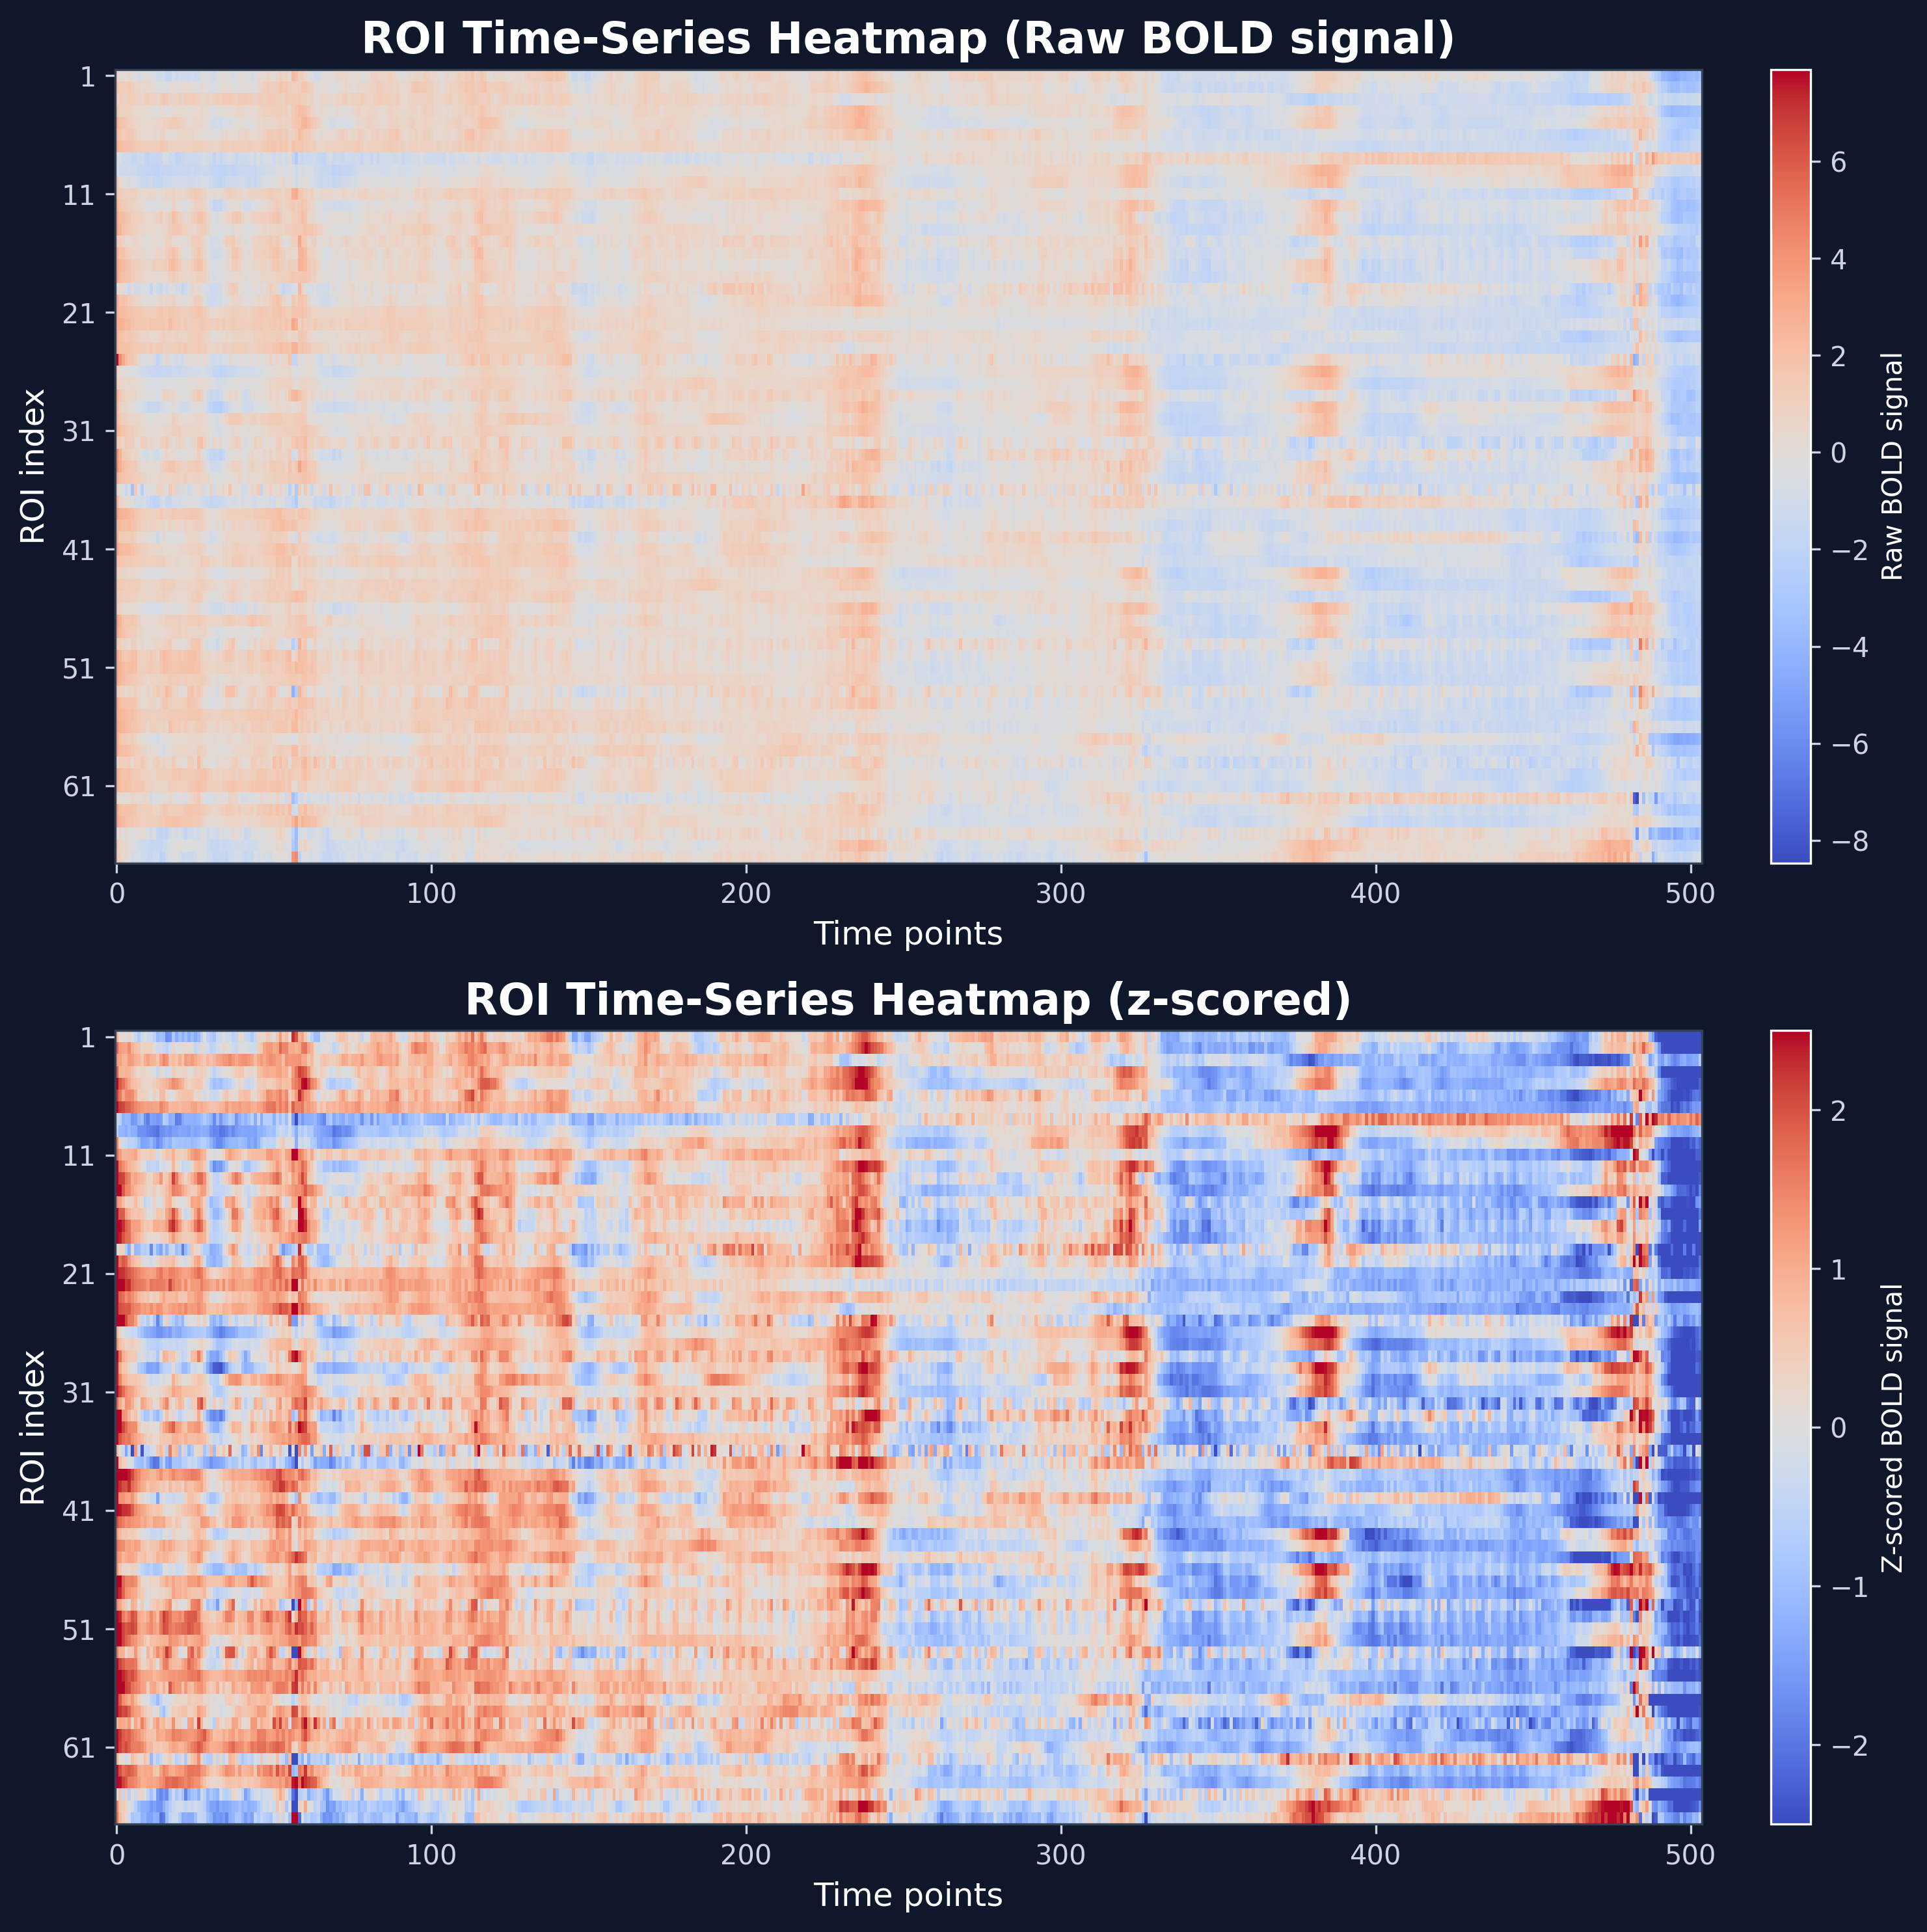

Saved: /content/roi_timeseries_heatmap_dark_combined.png


In [28]:
import matplotlib.pyplot as plt

# plot double heatmaps (Raw vs Z-scored) ===
plt.style.use("dark_background")

# 建立 2x1 的子圖，高度拉長以容納兩張圖
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), dpi=300)

# 將兩組資料與其對應的設定打包，方便透過迴圈處理
# 請確保 'ts' 是你的原始資料變數名稱
plot_configs = [
    {
        "data": ts.T,
        "title": "ROI Time-Series Heatmap (Raw BOLD signal)",
        "label": "Raw BOLD signal",
        "vmin": None, # 原始資料通常不設限，由 matplotlib 自動抓取最大最小值
        "vmax": None
    },
    {
        "data": ts_z.T,
        "title": "ROI Time-Series Heatmap (z-scored)",
        "label": "Z-scored BOLD signal",
        "vmin": -2.5,
        "vmax": 2.5
    }
]

for ax, config in zip(axes, plot_configs):
    # 繪製熱圖
    im = ax.imshow(
        config["data"],
        aspect="auto",
        cmap="coolwarm",
        interpolation="nearest",
        vmin=config["vmin"],
        vmax=config["vmax"]
    )

    # 設定標題與軸標籤
    ax.set_title(config["title"], fontsize=16, weight="bold", color="white")
    ax.set_xlabel("Time points", fontsize=12, color="white")
    ax.set_ylabel("ROI index", fontsize=12, color="white")

    # 設定 Y 軸刻度
    ax.set_yticks(np.arange(0, config["data"].shape[0], 10))
    ax.set_yticklabels(np.arange(1, config["data"].shape[0] + 1, 10))
    ax.tick_params(colors="#cbd5e1")

    # 統一背景與邊框顏色
    ax.set_facecolor("#0f172a")
    for spine in ax.spines.values():
        spine.set_color("#334155")

    # 為每個子圖加上獨立的 Colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(config["label"], color="white")
    cbar.ax.yaxis.set_tick_params(color="#cbd5e1")
    plt.setp(cbar.ax.get_yticklabels(), color="#cbd5e1")

# 設定整張畫布的背景色
fig.patch.set_facecolor("#0f172a")

# 輸出儲存
out = "/content/roi_timeseries_heatmap_dark_combined.png"
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Saved:", out)

### original heatmap code

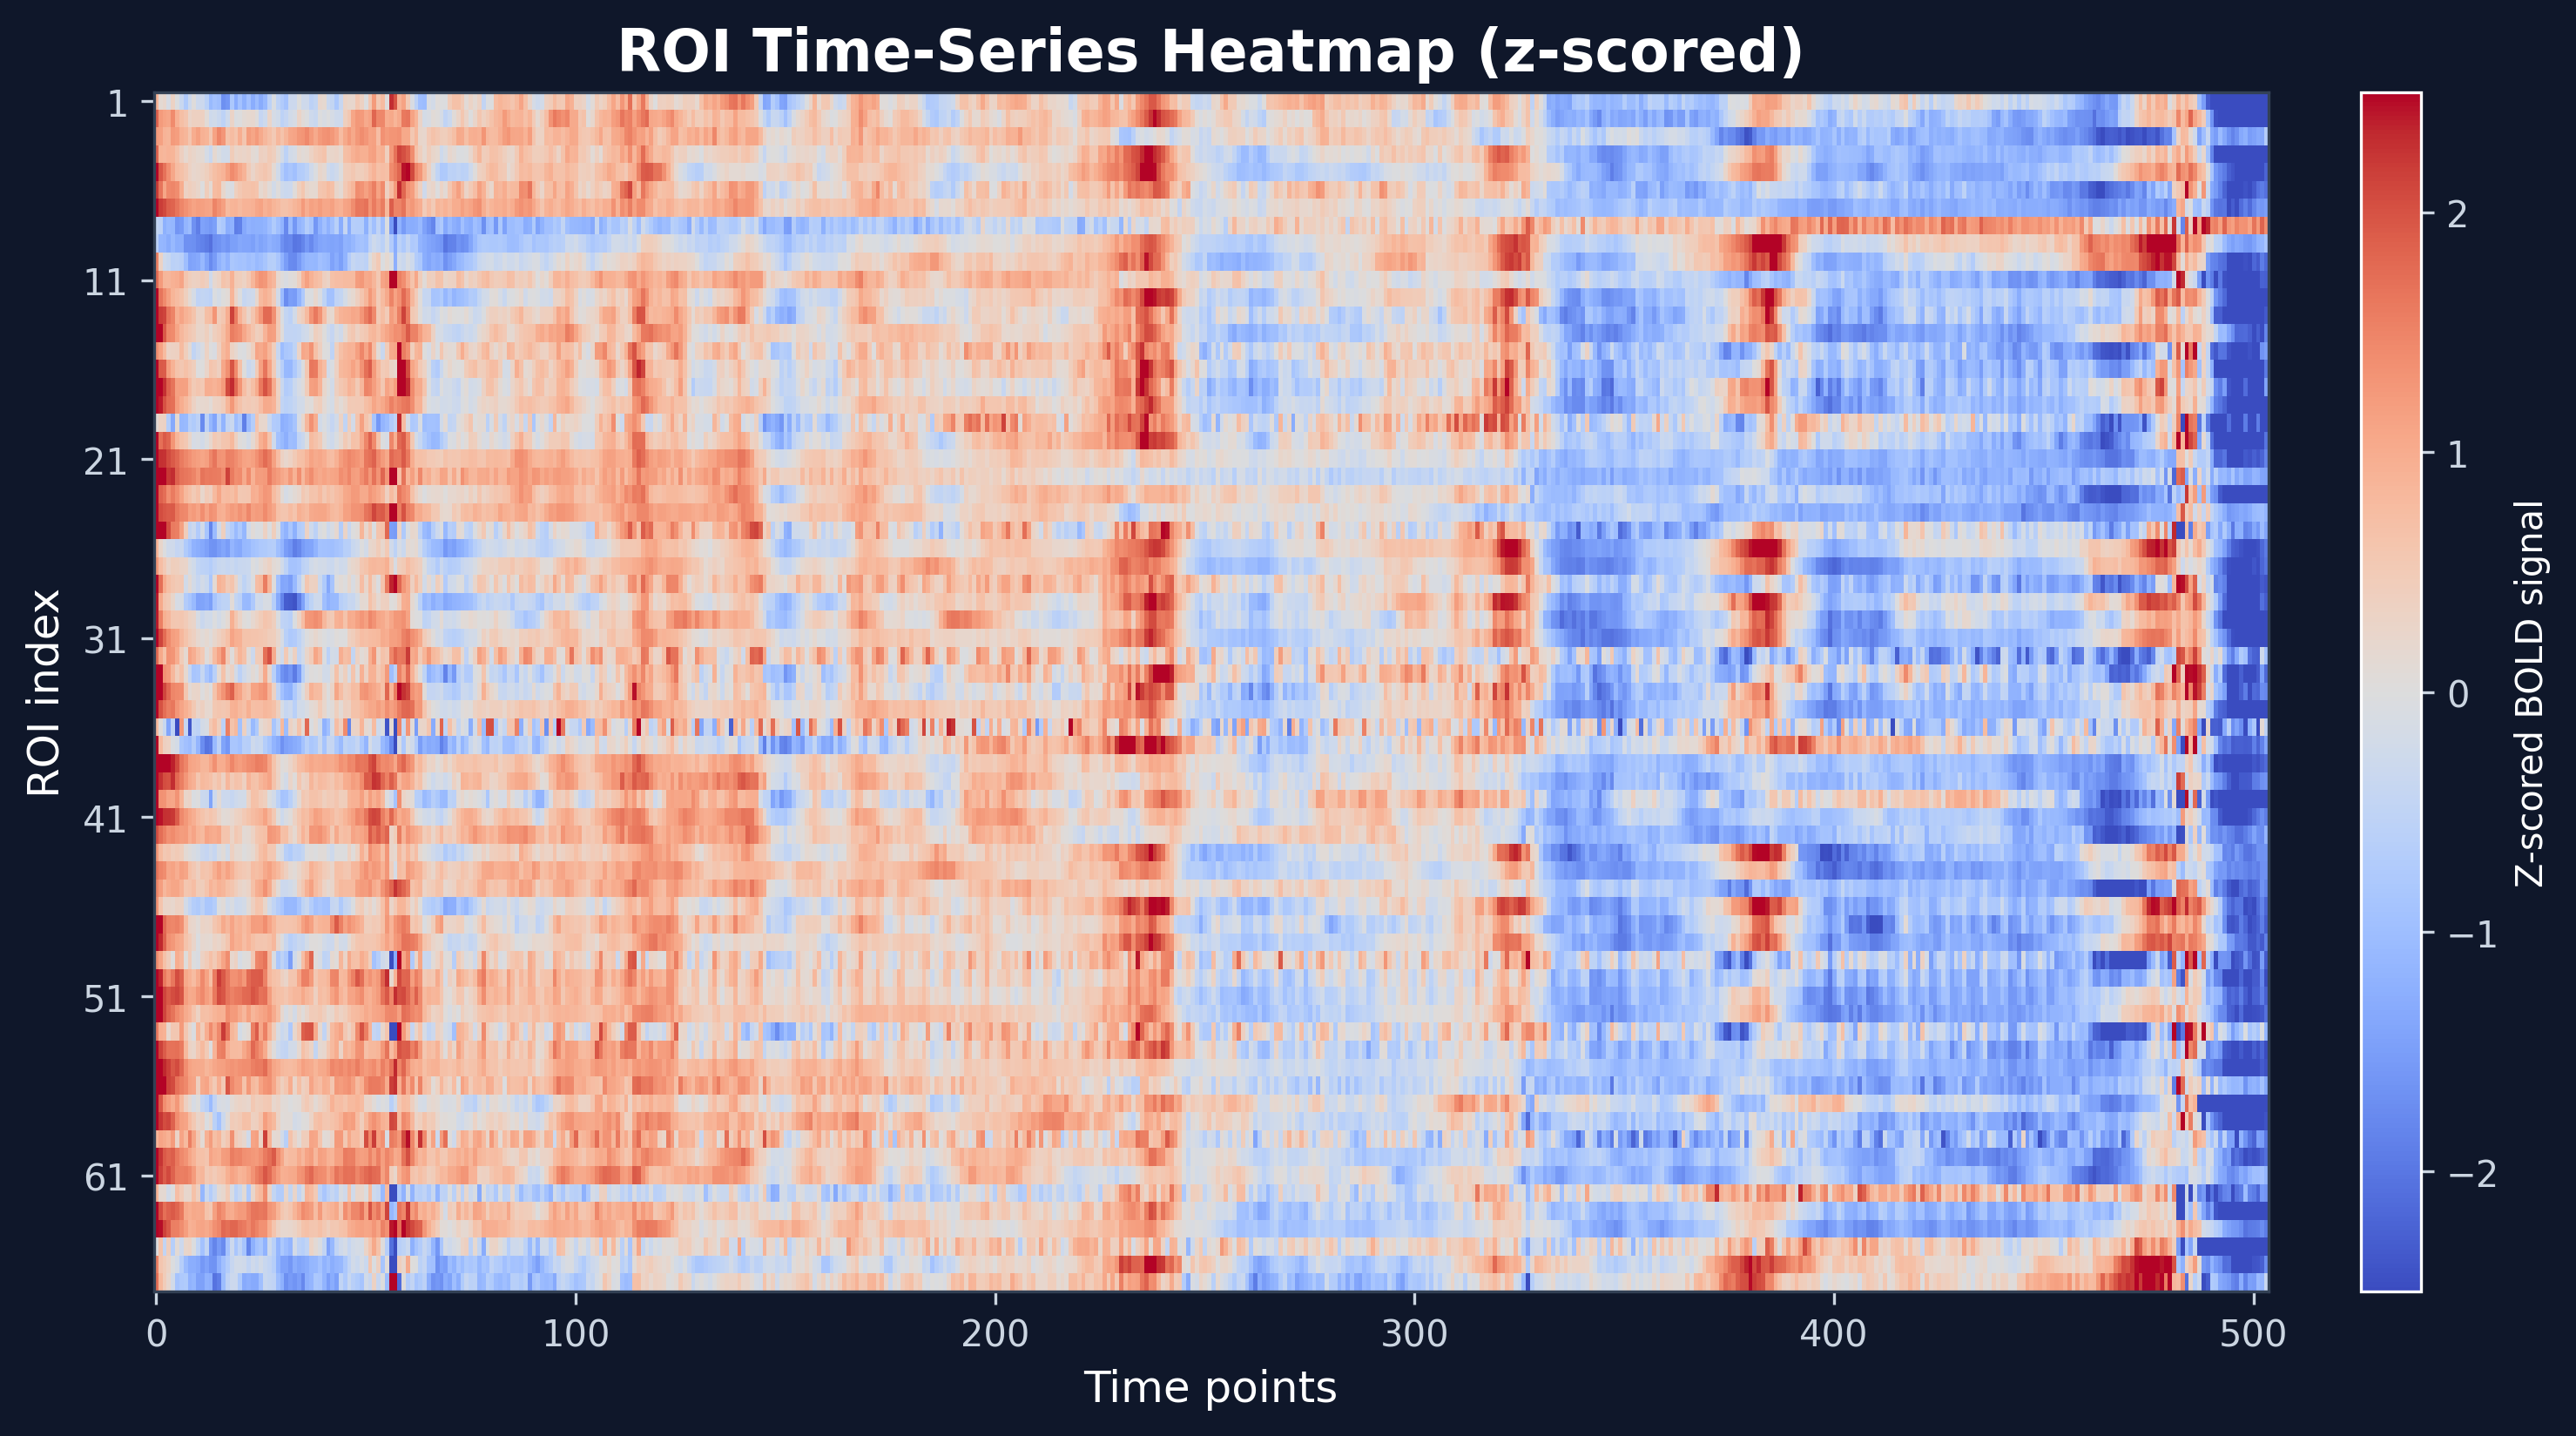

Saved: /content/roi_timeseries_heatmap_dark.png


In [31]:
# original: plot z-score heatmap
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(10, 5.6), dpi=300)

im = ax.imshow(
    ts_z.T,
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
    vmin=-2.5,
    vmax=2.5
)

ax.set_title("ROI Time-Series Heatmap (z-scored)", fontsize=16, weight="bold", color="white")
ax.set_xlabel("Time points", fontsize=12, color="white")
ax.set_ylabel("ROI index", fontsize=12, color="white")

ax.set_yticks(np.arange(0, ts_z.shape[1], 10))
ax.set_yticklabels(np.arange(1, ts_z.shape[1] + 1, 10))
ax.tick_params(colors="#cbd5e1")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Z-scored BOLD signal", color="white")
cbar.ax.yaxis.set_tick_params(color="#cbd5e1")
plt.setp(cbar.ax.get_yticklabels(), color="#cbd5e1")

fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#0f172a")
for spine in ax.spines.values():
    spine.set_color("#334155")

out = "/content/roi_timeseries_heatmap_dark.png"
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Saved:", out)

## sFC

### sFC matrices

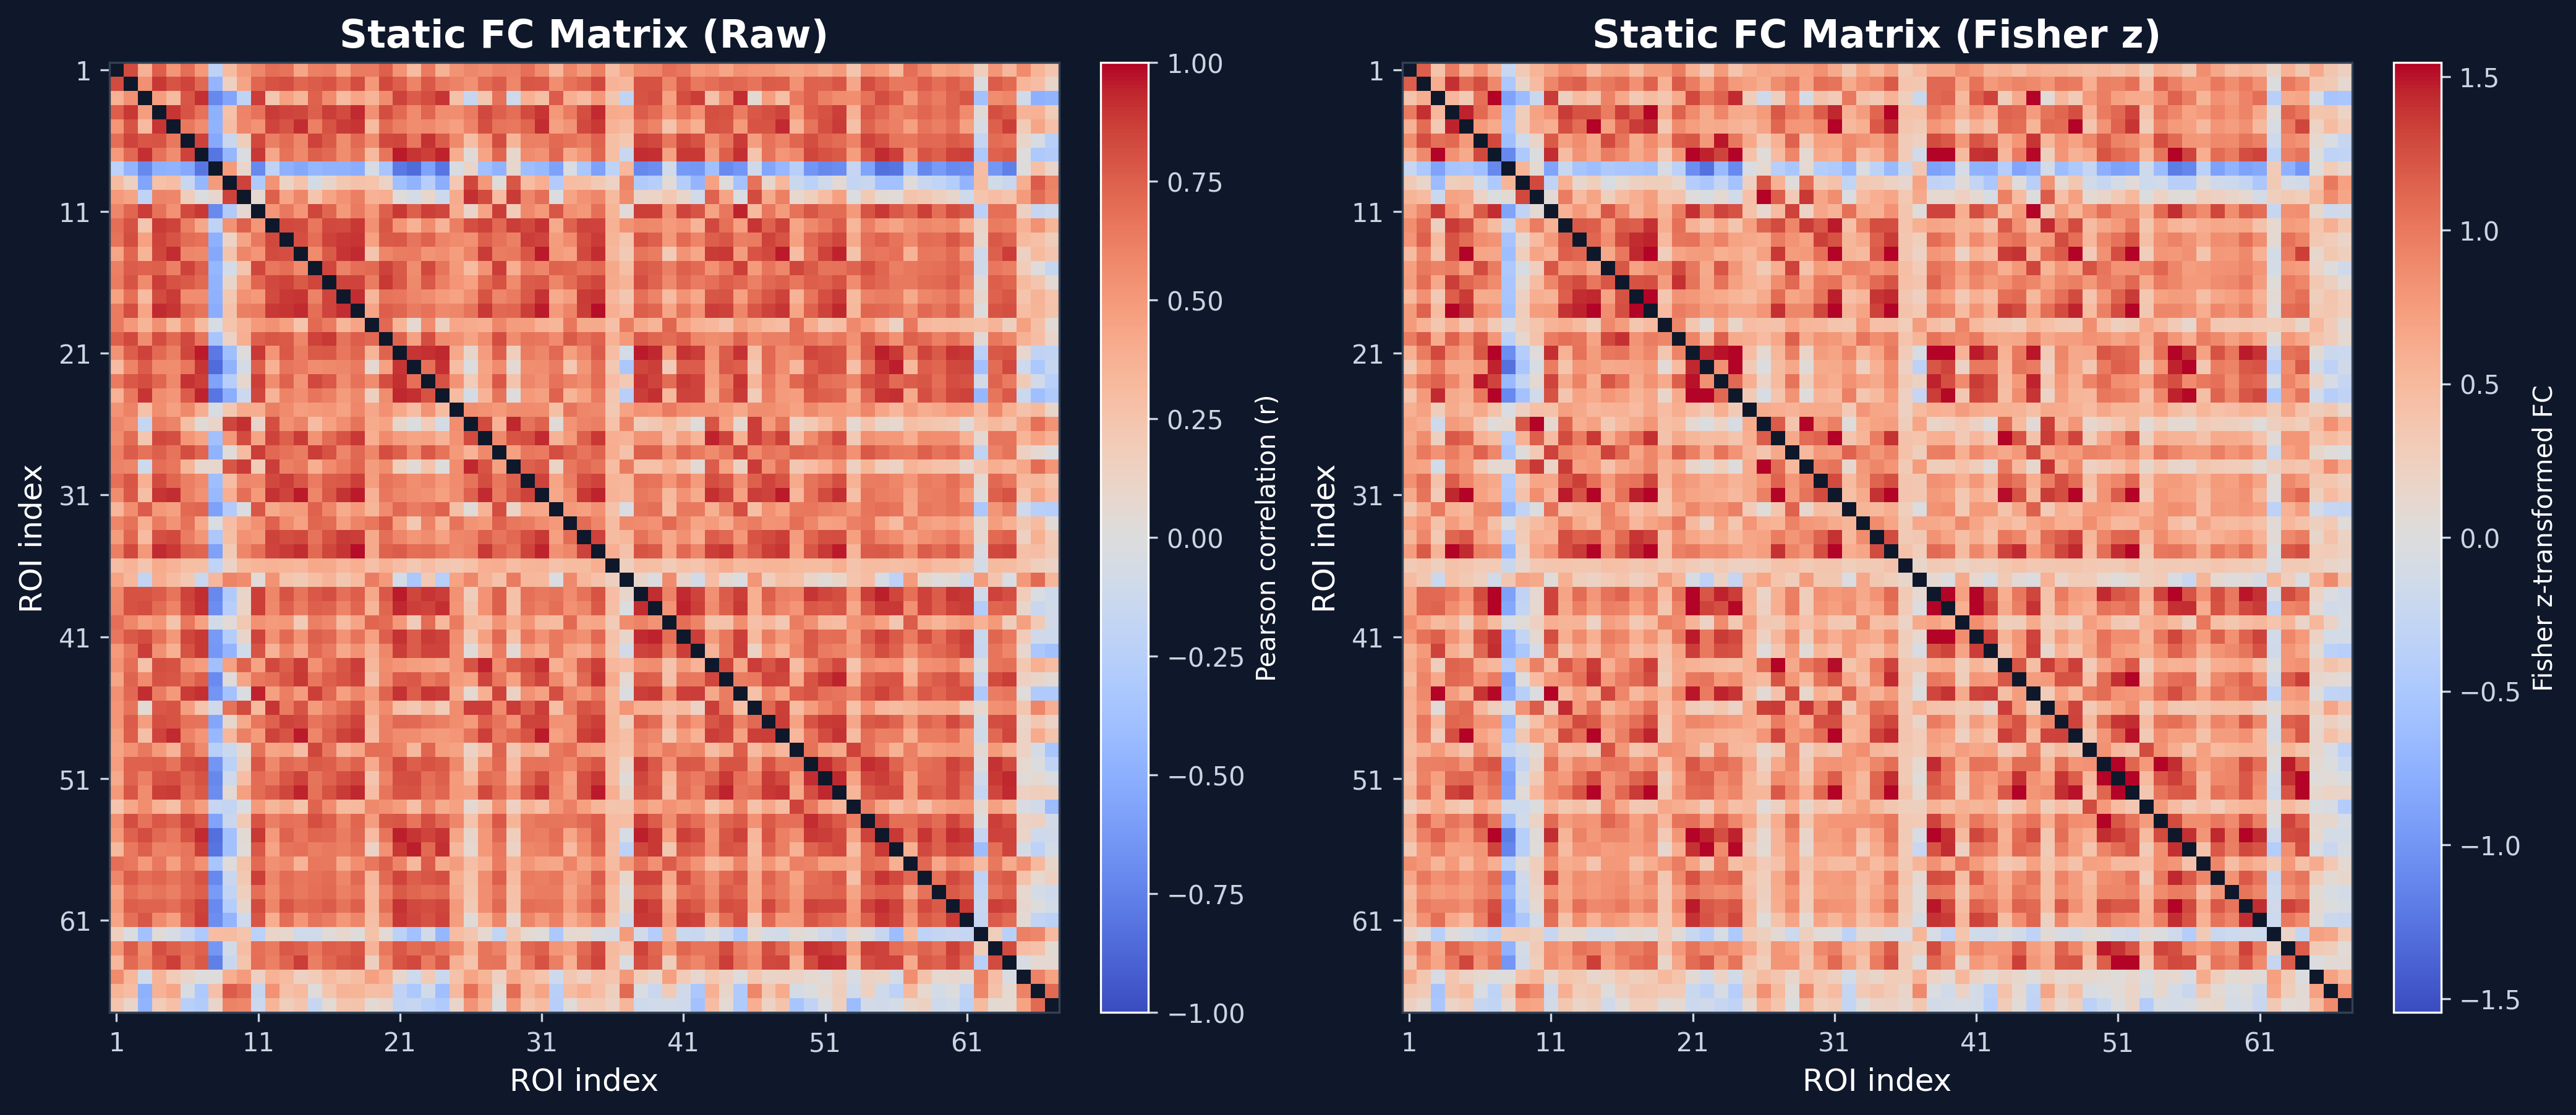

Saved: /content/static_fc_combined_dark.png


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === 1) Load Both Matrices ===
# 讀取並處理 Raw sFC
fc_raw_path = "/content/sub-PC001_ses-01_task-rest_run-1_static_fc.csv"
fc_raw = pd.read_csv(fc_raw_path, index_col=0).values.astype(float)
np.fill_diagonal(fc_raw, np.nan) # Mask diagonal

# 讀取並處理 Fisher-z sFC
fc_z_path = "/content/sub-PC001_ses-01_task-rest_run-1_static_fc_fisher_z.csv"
fc_z = pd.read_csv(fc_z_path, index_col=0).values.astype(float)
np.fill_diagonal(fc_z, np.nan) # Mask diagonal

# 計算 Fisher-z 較為 robust 的極值 (排除極端 outliers)
vmax_z = np.nanpercentile(np.abs(fc_z), 98)

# === 2) Setup Plotting Configuration ===
plt.style.use("dark_background")

# 建立 1x2 的子圖 (左右並列)，稍微拉寬 figsize
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6), dpi=300)

plot_configs = [
    {
        "data": fc_raw,
        "title": "Static FC Matrix (Raw)",
        "label": "Pearson correlation (r)",
        "vmin": -1, # 原始 Pearson r 介於 -1 到 1
        "vmax": 1
    },
    {
        "data": fc_z,
        "title": "Static FC Matrix (Fisher z)",
        "label": "Fisher z-transformed FC",
        "vmin": -vmax_z, # 使用 98% 百分位數作為極值
        "vmax": vmax_z
    }
]

# === 3) Plot Loop ===
# 共用的座標軸刻度設定
n_roi = fc_raw.shape[0]
tick_positions = np.arange(0, n_roi, 10)
tick_labels = np.arange(1, n_roi + 1, 10)

for ax, config in zip(axes, plot_configs):
    im = ax.imshow(
        config["data"],
        cmap="coolwarm",
        vmin=config["vmin"],
        vmax=config["vmax"],
        interpolation="nearest"
    )

    ax.set_title(config["title"], fontsize=15, weight="bold", color="white")
    ax.set_xlabel("ROI index", fontsize=12, color="white")
    ax.set_ylabel("ROI index", fontsize=12, color="white")

    # 設定 XY 軸刻度
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(tick_labels)
    ax.tick_params(colors="#cbd5e1")

    # 統一背景與邊框顏色
    ax.set_facecolor("#0f172a")
    for spine in ax.spines.values():
        spine.set_color("#334155")

    # 為每個子圖加上獨立的 Colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(config["label"], color="white")
    cbar.ax.yaxis.set_tick_params(color="#cbd5e1")
    plt.setp(cbar.ax.get_yticklabels(), color="#cbd5e1")

# 設定整張畫布的背景色
fig.patch.set_facecolor("#0f172a")

# 輸出儲存
out = "/content/static_fc_combined_dark.png"
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Saved:", out)

In [11]:
# optional section (搜尋目前 Colab 工作目錄底下有沒有 metadata 相關檔案)
from pathlib import Path

for p in Path(".").rglob("*"):
    name = p.name.lower()
    if any(k in name for k in ["participants", "sessions", "scans", "events", "phenotype", "readme", "dataset"]):
        print(p)

sample_data/README.md


### sFC descriptive check

=== Distribution Stats ===
Number of edges: 2211
Mean FC: 0.4955 | SD FC: 0.3339
Proportion pos: 0.91 | Proportion neg: 0.09

=== Node Strength Stats ===
Mean node strength: 0.4955
Max node strength ROI: 35 (0.6633)
Min node strength ROI: 8 (-0.4129)


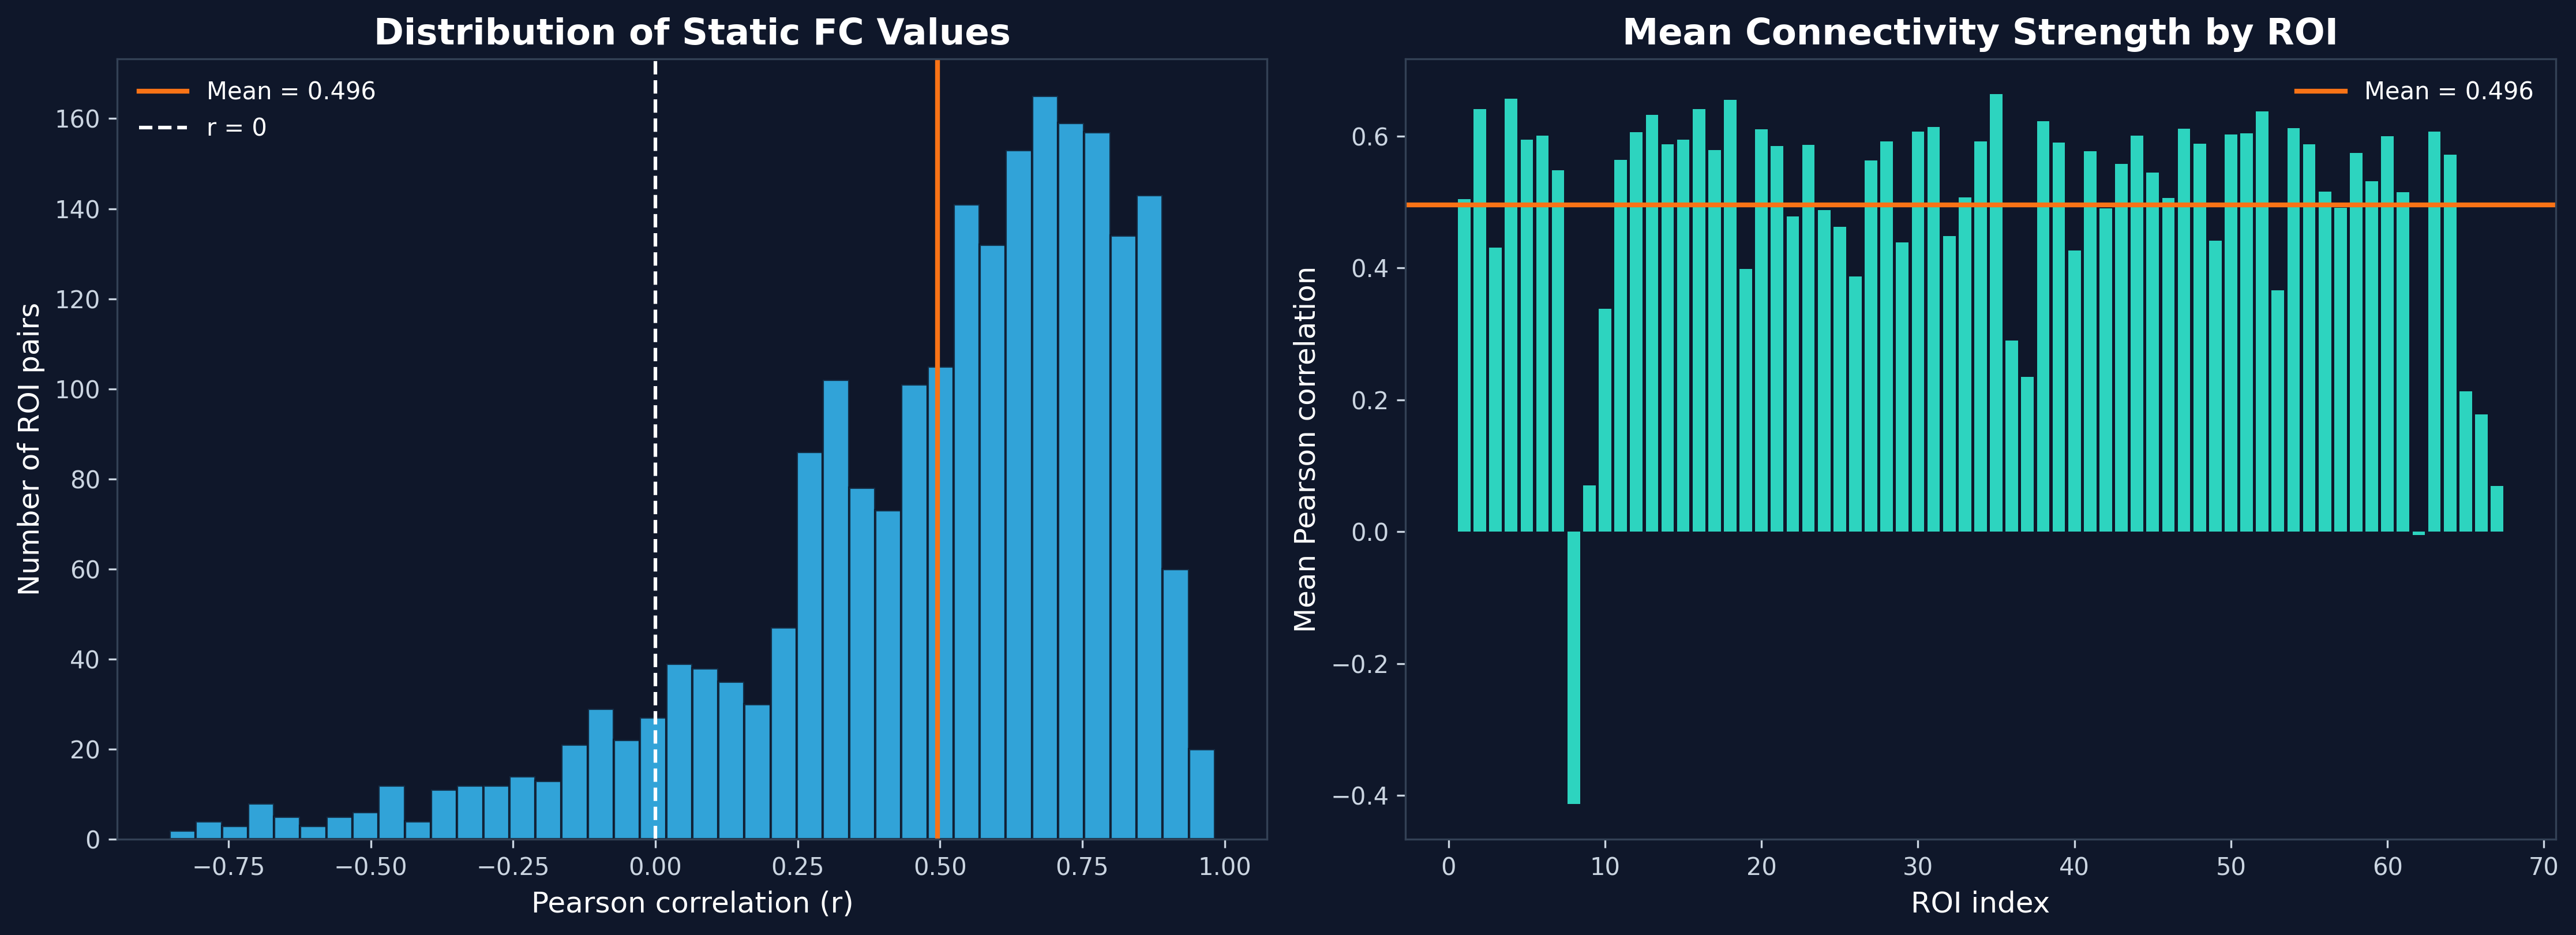


Saved combined image to: /content/static_fc_stats_combined_dark.png


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === 1) Load Static FC ===
fc_path = "/content/sub-PC001_ses-01_task-rest_run-1_static_fc.csv"
fc_df = pd.read_csv(fc_path, index_col=0)
fc = fc_df.values.astype(float)

# === 2) Compute Data for Plot 1 (Histogram) ===
n = fc.shape[0]
upper_idx = np.triu_indices(n, k=1)
edges = fc[upper_idx]

print("=== Distribution Stats ===")
print(f"Number of edges: {len(edges)}")
print(f"Mean FC: {np.mean(edges):.4f} | SD FC: {np.std(edges):.4f}")
print(f"Proportion pos: {np.mean(edges > 0):.2f} | Proportion neg: {np.mean(edges < 0):.2f}")

# === 3) Compute Data for Plot 2 (Node Strength) ===
fc_no_diag = fc.copy()
np.fill_diagonal(fc_no_diag, np.nan)
node_strength = np.nanmean(fc_no_diag, axis=1)

print("\n=== Node Strength Stats ===")
print(f"Mean node strength: {np.mean(node_strength):.4f}")
print(f"Max node strength ROI: {np.argmax(node_strength) + 1} ({np.max(node_strength):.4f})")
print(f"Min node strength ROI: {np.argmin(node_strength) + 1} ({np.min(node_strength):.4f})")

# === 4) Plot Combined Figure ===
plt.style.use("dark_background")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5.5), dpi=300)

# --- Subplot 1: Histogram (axes[0]) ---
ax1 = axes[0]
ax1.hist(edges, bins=40, color="#38bdf8", alpha=0.85, edgecolor="#0f172a")
ax1.axvline(np.mean(edges), color="#f97316", linewidth=2, label=f"Mean = {np.mean(edges):.3f}")
ax1.axvline(0, color="white", linewidth=1.5, linestyle="--", label="r = 0")
ax1.set_title("Distribution of Static FC Values", fontsize=15, weight="bold", color="white")
ax1.set_xlabel("Pearson correlation (r)", fontsize=12, color="white")
ax1.set_ylabel("Number of ROI pairs", fontsize=12, color="white")
ax1.legend(frameon=False, labelcolor="white")

# --- Subplot 2: Bar Chart (axes[1]) ---
ax2 = axes[1]
ax2.bar(np.arange(1, len(node_strength) + 1), node_strength, color="#2dd4bf")
ax2.axhline(np.mean(node_strength), color="#f97316", linewidth=2, label=f"Mean = {np.mean(node_strength):.3f}")
ax2.set_title("Mean Connectivity Strength by ROI", fontsize=15, weight="bold", color="white")
ax2.set_xlabel("ROI index", fontsize=12, color="white")
ax2.set_ylabel("Mean Pearson correlation", fontsize=12, color="white")
ax2.legend(frameon=False, labelcolor="white")

# --- Global Style Adjustments ---
fig.patch.set_facecolor("#0f172a")
for ax in axes:
    ax.set_facecolor("#0f172a")
    ax.tick_params(colors="#cbd5e1")
    for spine in ax.spines.values():
        spine.set_color("#334155")

# Save and show
out = "/content/static_fc_stats_combined_dark.png"
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print(f"\nSaved combined image to: {out}")

## dFC

### upload fc_dfc.zip

In [36]:
from google.colab import files
uploaded = files.upload()

Saving fc_dfc.zip to fc_dfc.zip


In [37]:
import zipfile
import os

zip_path = "/content/fc_dfc.zip"
out_dir = "/content/fc_dfc"

os.makedirs(out_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(out_dir)

print("Extracted files:")
print(os.listdir(out_dir)[:10])

Extracted files:
['fc_dfc', '__MACOSX']


In [39]:
from pathlib import Path
import re

folder = Path("/content/fc_dfc")

window_files = sorted(folder.rglob("sub-PC001_ses-01_task-rest_run-1_window-*_fc_fisher_z.csv"))

print("Number of window files found:", len(window_files))

for f in window_files[:5]:
    print("Example file:", f.name)

if len(window_files) == 0:
    raise FileNotFoundError("No window files found. Check your folder path.")


Number of window files found: 45
Example file: sub-PC001_ses-01_task-rest_run-1_window-000_fc_fisher_z.csv
Example file: sub-PC001_ses-01_task-rest_run-1_window-001_fc_fisher_z.csv
Example file: sub-PC001_ses-01_task-rest_run-1_window-002_fc_fisher_z.csv
Example file: sub-PC001_ses-01_task-rest_run-1_window-003_fc_fisher_z.csv
Example file: sub-PC001_ses-01_task-rest_run-1_window-004_fc_fisher_z.csv


In [40]:
def get_window_id(path):
    match = re.search(r"window-(\d+)", path.name)
    if match is None:
        raise ValueError(f"Cannot parse window id from {path.name}")
    return int(match.group(1))

window_files = sorted(window_files, key=get_window_id)
window_ids = np.array([get_window_id(f) for f in window_files])

print("Window IDs:", window_ids[:10], "...", window_ids[-5:])
print("Number of windows:", len(window_ids))

Window IDs: [0 1 2 3 4 5 6 7 8 9] ... [40 41 42 43 44]
Number of windows: 45


In [41]:
mats = []

for f in window_files:
    df = pd.read_csv(f, index_col=0)
    mat = df.values.astype(float)

    # basic check
    if mat.shape != (67, 67):
        raise ValueError(f"Unexpected shape {mat.shape} in {f.name}")

    # mask diagonal because Fisher z diagonal is artificially large
    np.fill_diagonal(mat, np.nan)

    mats.append(mat)

mats = np.stack(mats, axis=0)  # shape: windows x ROI x ROI

print("dFC array shape:", mats.shape)
print("Expected: number_of_windows x 67 x 67")
print("Min:", np.nanmin(mats))
print("Max:", np.nanmax(mats))


dFC array shape: (45, 67, 67)
Expected: number_of_windows x 67 x 67
Min: -1.487013801574164
Max: 2.92074843352411


### dFC 1: Mean connectivity across sliding windows

Mean of window-level mean FC: 0.5054830249816703
SD of window-level mean FC: 0.1655302963321182
Min window mean FC: 0.13556253387646966
Max window mean FC: 0.8434206111162366


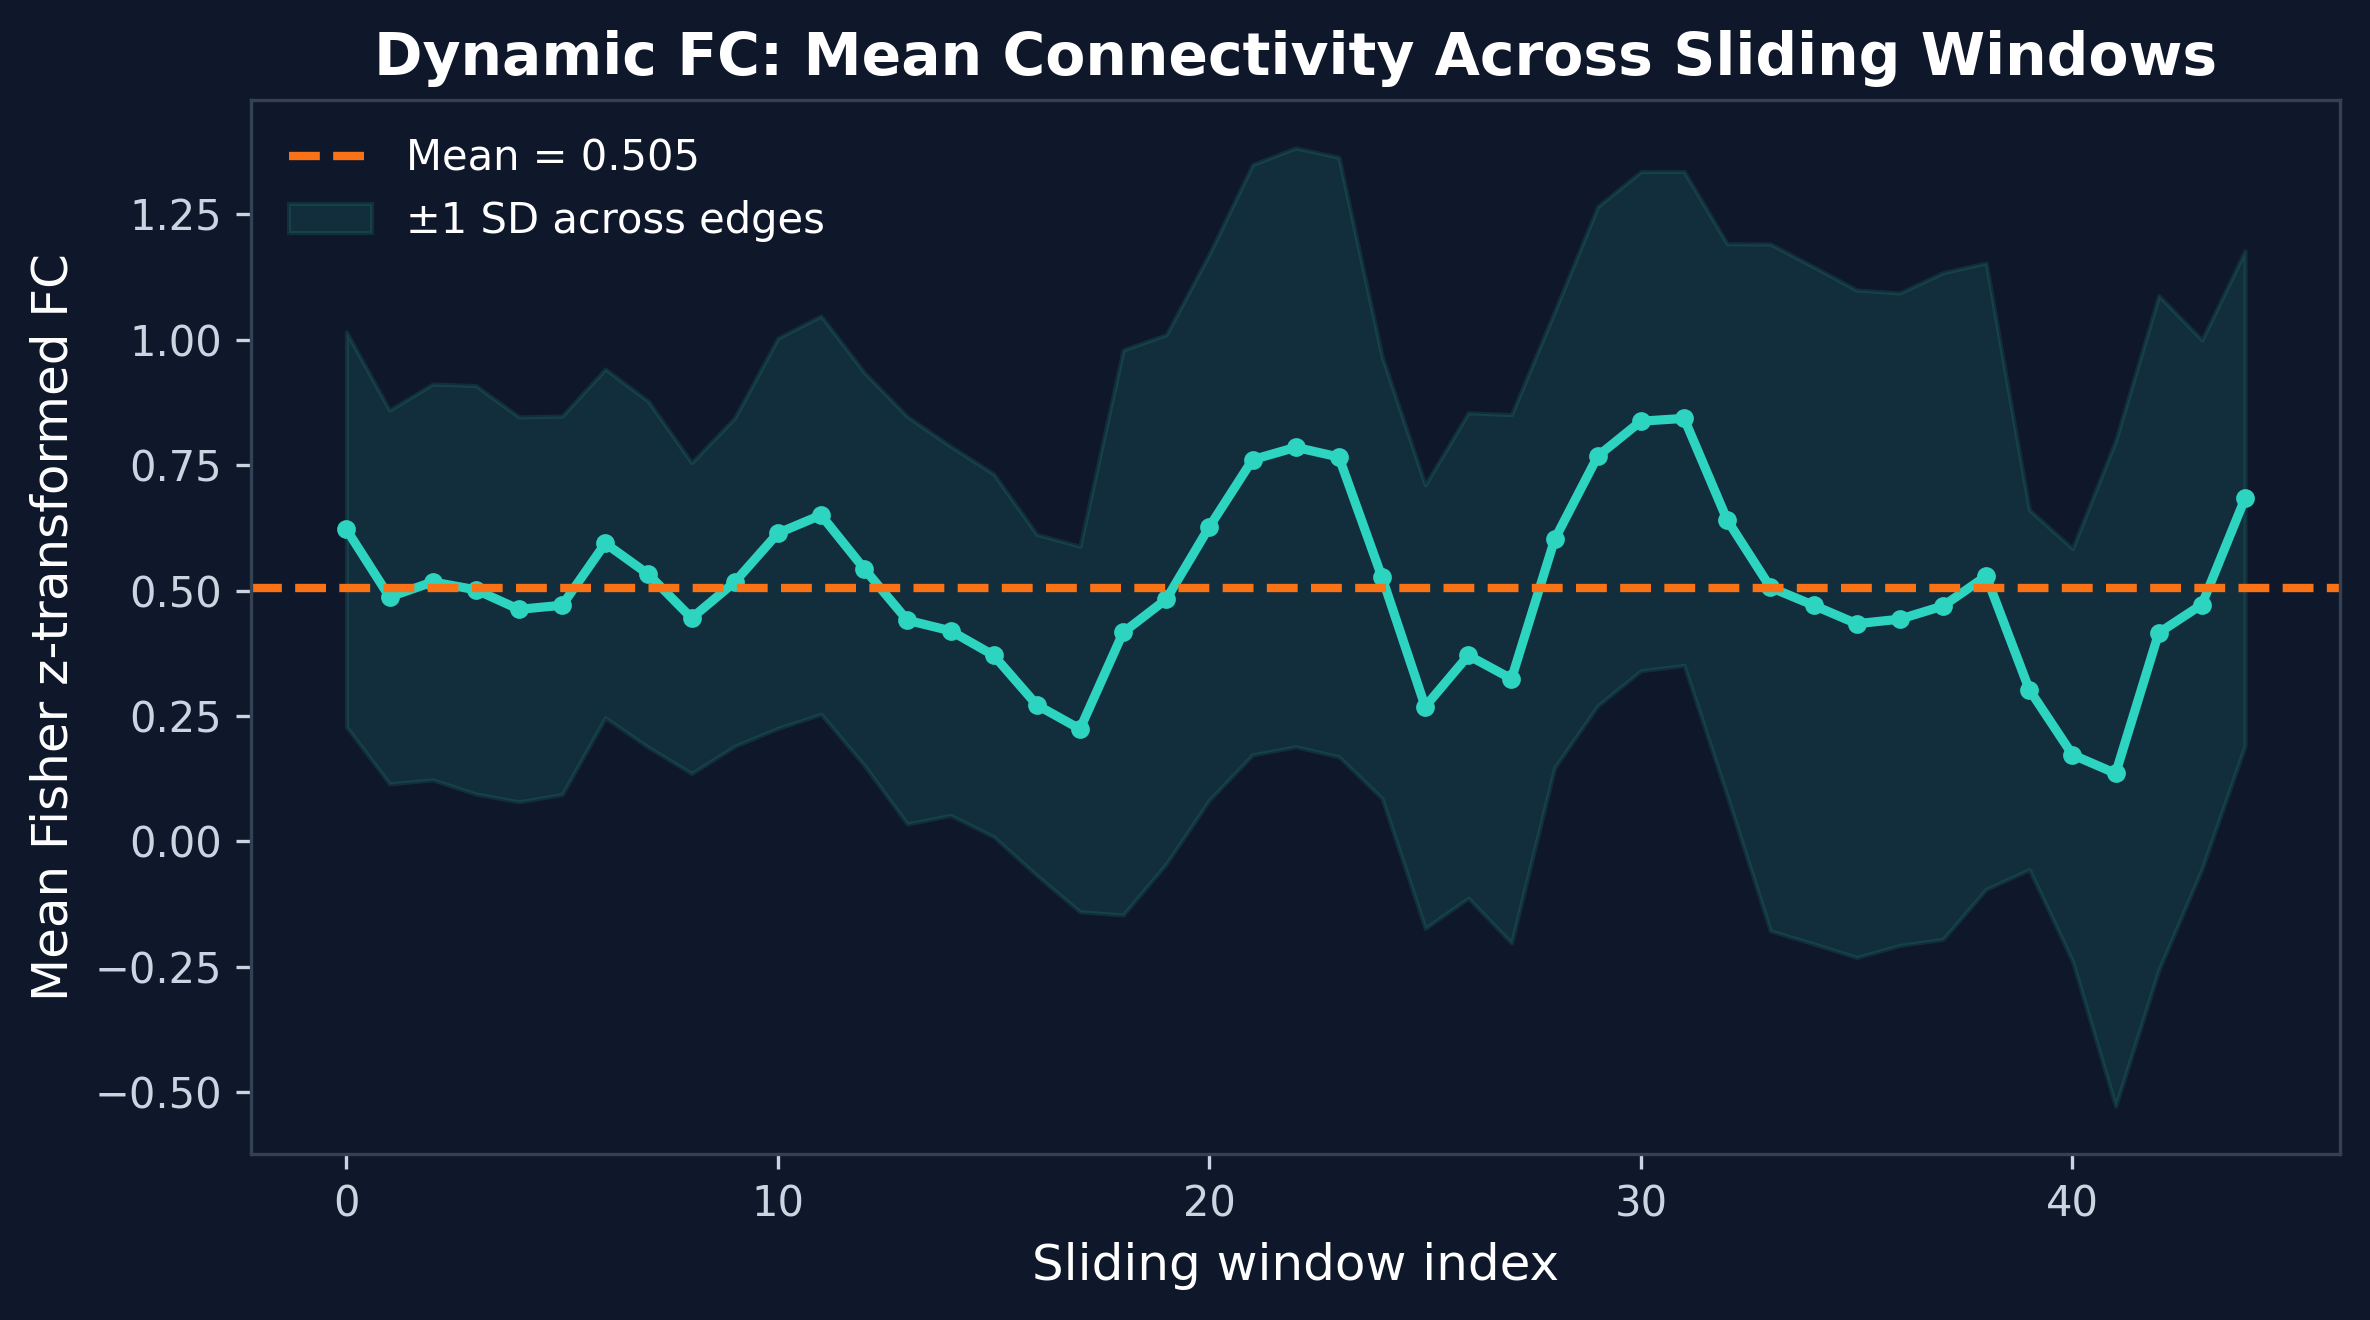

Saved: /content/dfc_mean_connectivity_timecourse_dark.png


In [42]:
# === compute mean and SD of edge values for each window ===
n_windows, n_roi, _ = mats.shape
upper_idx = np.triu_indices(n_roi, k=1)

mean_fc_per_window = []
sd_fc_per_window = []

for w in range(n_windows):
    edges = mats[w][upper_idx]
    mean_fc_per_window.append(np.nanmean(edges))
    sd_fc_per_window.append(np.nanstd(edges))

mean_fc_per_window = np.array(mean_fc_per_window)
sd_fc_per_window = np.array(sd_fc_per_window)

print("Mean of window-level mean FC:", np.mean(mean_fc_per_window))
print("SD of window-level mean FC:", np.std(mean_fc_per_window))
print("Min window mean FC:", np.min(mean_fc_per_window))
print("Max window mean FC:", np.max(mean_fc_per_window))

# === plot ===
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=300)

ax.plot(
    window_ids,
    mean_fc_per_window,
    color="#2dd4bf",
    linewidth=2.2,
    marker="o",
    markersize=3.5
)

ax.axhline(
    np.mean(mean_fc_per_window),
    color="#f97316",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {np.mean(mean_fc_per_window):.3f}"
)

ax.fill_between(
    window_ids,
    mean_fc_per_window - sd_fc_per_window,
    mean_fc_per_window + sd_fc_per_window,
    color="#2dd4bf",
    alpha=0.12,
    label="±1 SD across edges"
)

ax.set_title("Dynamic FC: Mean Connectivity Across Sliding Windows", fontsize=14, weight="bold", color="white")
ax.set_xlabel("Sliding window index", fontsize=12, color="white")
ax.set_ylabel("Mean Fisher z-transformed FC", fontsize=12, color="white")

ax.tick_params(colors="#cbd5e1")
ax.legend(frameon=False, labelcolor="white")

fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#0f172a")

for spine in ax.spines.values():
    spine.set_color("#334155")

out = "/content/dfc_mean_connectivity_timecourse_dark.png"
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Saved:", out)


/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


dFC variability matrix shape: (67, 67)
Min variability: 0.12050818507459042
Max variability: 0.6527249362741745
Mean variability: 0.3606209564757253


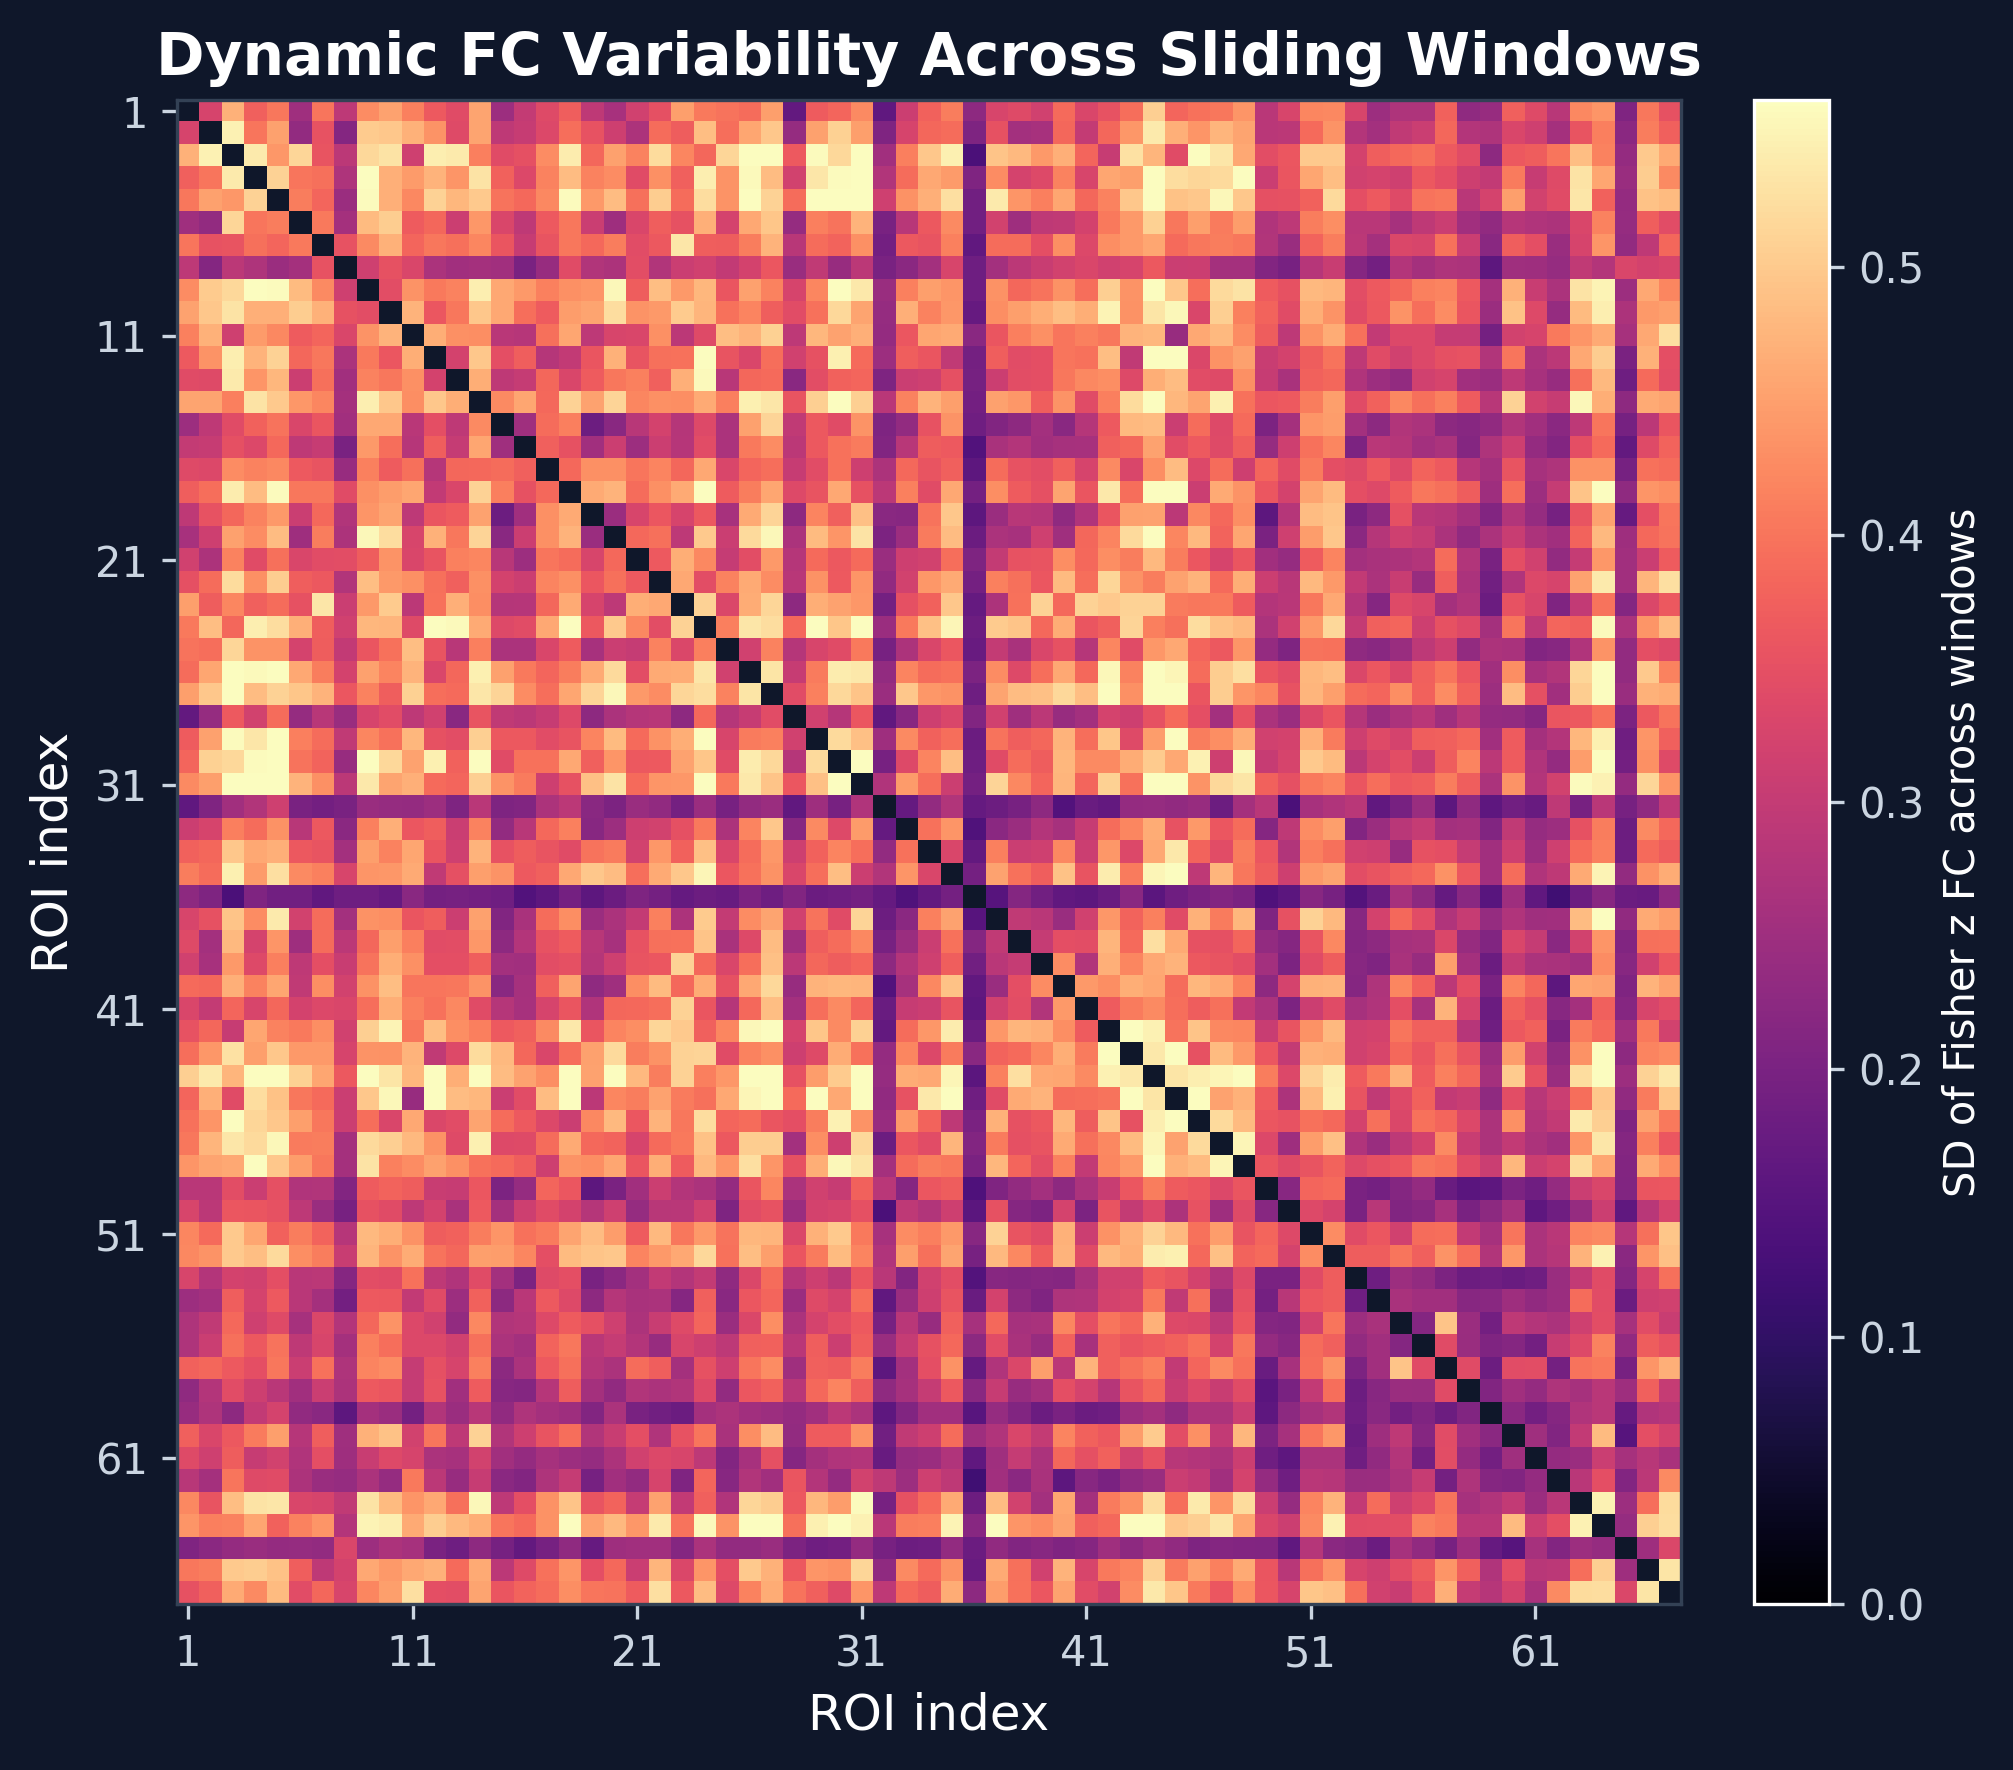

Saved: /content/dfc_variability_matrix_dark.png


In [43]:
# === compute temporal variability for each edge ===
dfc_var = np.nanstd(mats, axis=0)

# mask diagonal
np.fill_diagonal(dfc_var, np.nan)

print("dFC variability matrix shape:", dfc_var.shape)
print("Min variability:", np.nanmin(dfc_var))
print("Max variability:", np.nanmax(dfc_var))
print("Mean variability:", np.nanmean(dfc_var))

# robust color range
vmax = np.nanpercentile(dfc_var, 98)

# === plot ===
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

im = ax.imshow(
    dfc_var,
    cmap="magma",
    vmin=0,
    vmax=vmax,
    interpolation="nearest"
)

ax.set_title("Dynamic FC Variability Across Sliding Windows", fontsize=14, weight="bold", color="white")
ax.set_xlabel("ROI index", fontsize=12, color="white")
ax.set_ylabel("ROI index", fontsize=12, color="white")

tick_positions = np.arange(0, n_roi, 10)
tick_labels = np.arange(1, n_roi + 1, 10)

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels)

ax.tick_params(colors="#cbd5e1")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("SD of Fisher z FC across windows", color="white")
cbar.ax.yaxis.set_tick_params(color="#cbd5e1")
plt.setp(cbar.ax.get_yticklabels(), color="#cbd5e1")

fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#0f172a")

for spine in ax.spines.values():
    spine.set_color("#334155")

out = "/content/dfc_variability_matrix_dark.png"
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Saved:", out)

Edge vector array shape: (45, 2211)
Window similarity shape: (45, 45)
Min: 0.11839103228557638
Max: 1.0


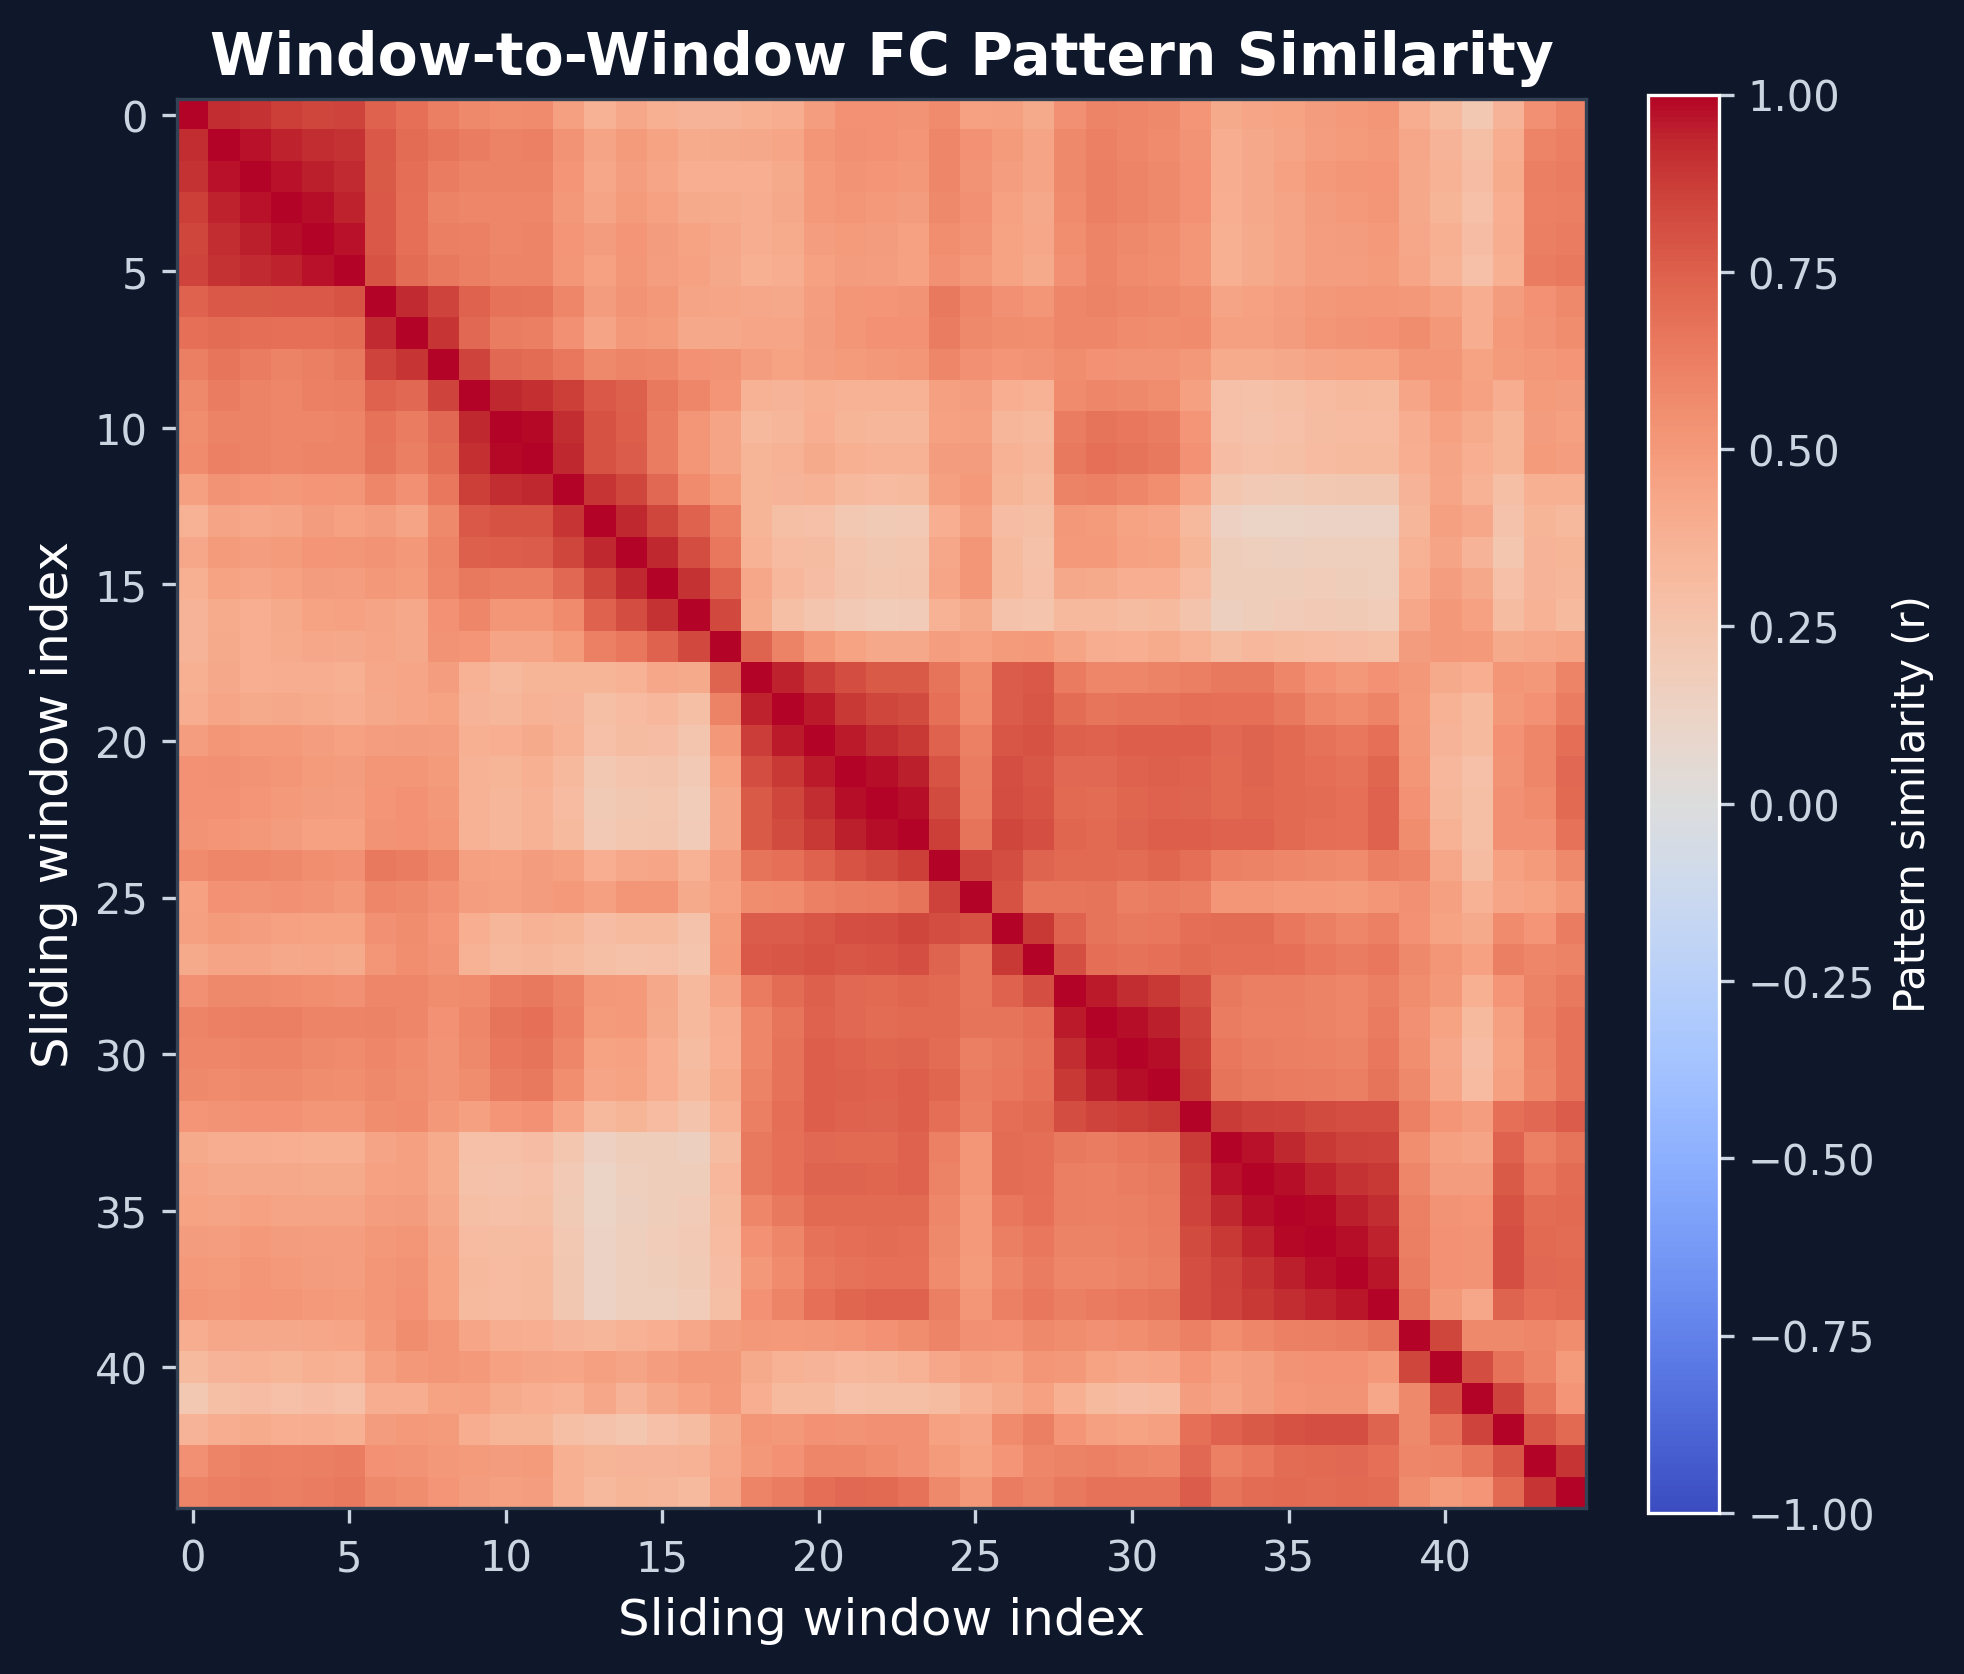

Saved: /content/window_to_window_fc_similarity_dark.png


In [44]:
# === vectorize each window's upper triangle ===
edge_vectors = []

for w in range(n_windows):
    edges = mats[w][upper_idx]
    edge_vectors.append(edges)

edge_vectors = np.array(edge_vectors)  # windows x edges

print("Edge vector array shape:", edge_vectors.shape)

# === compute window-to-window similarity ===
# correlation between window FC patterns
window_similarity = np.corrcoef(edge_vectors)

print("Window similarity shape:", window_similarity.shape)
print("Min:", np.nanmin(window_similarity))
print("Max:", np.nanmax(window_similarity))

# === plot ===
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(6.5, 5.8), dpi=300)

im = ax.imshow(
    window_similarity,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    interpolation="nearest"
)

ax.set_title("Window-to-Window FC Pattern Similarity", fontsize=14, weight="bold", color="white")
ax.set_xlabel("Sliding window index", fontsize=12, color="white")
ax.set_ylabel("Sliding window index", fontsize=12, color="white")

ax.tick_params(colors="#cbd5e1")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pattern similarity (r)", color="white")
cbar.ax.yaxis.set_tick_params(color="#cbd5e1")
plt.setp(cbar.ax.get_yticklabels(), color="#cbd5e1")

fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#0f172a")

for spine in ax.spines.values():
    spine.set_color("#334155")

out = "/content/window_to_window_fc_similarity_dark.png"
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Saved:", out)
